In [2]:
import numpy as np
import math as math
import matplotlib.pyplot as plt

# Mass calculations with diameter = 50 um
Below I do a mass calculation using one single given diameter, then I change diameter to radius, use it to find the volume, and then given a density of ethanol, I do mass calculations

In [3]:
##First step to a m/q calculation is a mass calculation. 
##I have an approximate diameter of particles i've trapped, and the density of ethanol so we can find the mass

##1st, Find radius given diameter
diameter_microns=50 #55.4795964
radius_microns = (diameter_microns)/2

print('Drop radius in Microns', radius_microns)

##To change radius from um to m
radius_meters= radius_microns/(1*10**6)
print('Drop radius in meters', radius_meters)

Drop radius in Microns 25.0
Drop radius in meters 2.5e-05


In [4]:
##now plug this into volume equation
drop_volume_cubic_microns = 4/3*math.pi*(radius_microns)**3
print('Drop volume in cubic Microns', drop_volume_cubic_microns)

##Convert volume from cubic microns to cubic meters
drop_volume_cubic_meters=drop_volume_cubic_microns/(1*10**18)
print('Drop volume in cubic meters', drop_volume_cubic_meters)


Drop volume in cubic Microns 65449.84694978735
Drop volume in cubic meters 6.544984694978735e-14


In [5]:
##Now to do mass calculations. D=m/v so Density*Volume = Mass
density_ethanol = 789 ##units are kg/m^3

drop_mass_kg = density_ethanol * drop_volume_cubic_meters
print('Drop mass in kilograms', drop_mass_kg)

##Convert Kg to ng
drop_mass_ng = drop_mass_kg * (1*10**12) 
print('Drop mass in nanograms', drop_mass_ng)

Drop mass in kilograms 5.163992924338222e-11
Drop mass in nanograms 51.63992924338222


# Mass calculations with array of measured diameters
This is the same process as above but I use an array of radii that I measured manually and Isabelle verified with code.

In [7]:
##tryna see if i can do the above with an array of radii
##these diameters are real measurements that Isabelle did with her code. they very closely match my manual measurements. 
##These diameters are recorded in notion at this link: https://www.notion.so/moorelab/30-June-222c5d00acc280e19045c09c4efb826d

diameter_microns_measured=np.array([49.866493,52.0346,54.92541,52.0346,54.20271,53.118656,52.0346,52.0346,49.866493,54.20271,53.84136,54.20271,53.84136,53.118356])

radius_microns_measured= (diameter_microns_measured)/2 ##diameter to radii
drop_volume_cubic_microns_measured= 4/3*math.pi*(radius_microns_measured)**3 ##volume in cubic microns
drop_volume_cubic_meters_measured=drop_volume_cubic_microns_measured/(1*10**18) ##volume converted to cubic meters
drop_mass_kg_measured = density_ethanol * drop_volume_cubic_meters_measured ##mass in kg
drop_mass_ng_measured = drop_mass_kg_measured * (1*10**12)  ##converts mass to ng
print('Drop mass in nanograms', drop_mass_ng_measured)

Drop mass in nanograms [51.22737526 58.20392692 68.4534826  58.20392692 65.78677966 61.91799142
 58.20392692 58.20392692 51.22737526 65.78677966 64.47980117 65.78677966
 64.47980117 61.91694234]


# Mass calculations with representative range
Same process again, but I use a representative range that includes the radii i measured manually above

In [168]:
## This range encompasses drops sizes i used, but the above are exact diameters I measured

diameter_microns_array=np.array([range(46,53)])

radius_microns_array= (diameter_microns_array)/2 ##diameter to radii
drop_volume_cubic_microns_array= 4/3*math.pi*(radius_microns_array)**3 ##volume in cubic microns
drop_volume_cubic_meters_array=drop_volume_cubic_microns_array/(1*10**18) ##volume converted to cubic meters
drop_mass_kg_array = density_ethanol * drop_volume_cubic_meters_array ##mass in kg
drop_mass_ng_array = drop_mass_kg_array * (1*10**12)   ##converts mass to ng
print('Drop mass in nanograms', drop_mass_ng_array, 'Drop mass in ng')

Drop mass in nanograms [[40.21139322 42.89129899 45.68770444 48.60308828 51.63992924 54.80070603
  58.08789737]] Drop mass in ng


In [170]:
##converting radius_microns_array from microns to meters
##THIS RANGE IS REPRESENTATIVE
radius_meters_array = radius_microns_array/(1*10**6)
print(radius_meters_array, ' Radius in meters')


[[2.30e-05 2.35e-05 2.40e-05 2.45e-05 2.50e-05 2.55e-05 2.60e-05]]  Radius in meters


# Charge Calculations with diameter = 50 um, approximating as a conducting sphere
Below I do a single charge calculation given a diameter of 50 um (defined in first cell) and an electrospray voltage of 2kV

In [173]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
es_voltage =3000 #Voltages applied onto inkjet/electrospray

Q_1= es_voltage*4*math.pi*epsilon*radius_meters #Coulombs ##used radius=25um in meters of single drop that is defined in very first cell
print(Q_1, 'Coulombs')

##convert from Coulombs to elementary charges
charges = Q_1*(6.242*10**18)
print(charges, 'elementary charges')

8.344698406465208e-12 Coulombs
52087607.45315583 elementary charges


# Q/m ratio with diameter = 50 m , approximating as a conducting sphere

In [176]:
#charge to mass ratio using diameter of 50 um
Q_m_1=Q_1/drop_mass_kg
print(Q_m_1, 'C/kg approximating drop as a conducting sphere')

#print(drop_mass_kg_array, 'kg')

0.1615939163498099 C/kg approximating drop as a conducting sphere


# Charge calculation, approximating as a conducting sphere with diameter = 50 m, varying ES voltage

In [179]:
##Now onto charge calculations
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
voltage_array =np.array([450, 490, 800 ,900, 3000]) #Voltages applied onto inkjet/electrospray

Q = voltage_array*4*math.pi*epsilon*radius_meters #Coulombs ##used radius=25um in meters of single drop that is defined in very first cell
print(Q, 'Coulombs')

##convert from Coulombs to elementary charges
charges = Q*(6.242*10**18)
print(charges, 'elementary charges')

[1.25170476e-12 1.36296741e-12 2.22525291e-12 2.50340952e-12
 8.34469841e-12] Coulombs
[ 7813141.11797337  8507642.55068212 13890028.65417489 15626282.23594675
 52087607.45315583] elementary charges


# Q/m dia=50 um, varying ES voltages used

In [182]:
#charge to mass ratio using charges from varying ES voltages and diameter of 50um

print(drop_mass_kg, 'kg') #single number

Q_m=Q/drop_mass_kg ##this is a list bc i vary the voltage
print(Q_m, 'C/kg approximating drop as a conducting sphere')


5.163992924338222e-11 kg
[0.02423909 0.02639367 0.04309171 0.04847817 0.16159392] C/kg approximating drop as a conducting sphere


# Q/m, approximating as conducting sphere, with range of diameters, Elecrtrospray voltage of 3kV

In [185]:
##same as above, voltage is no longer varied.
##If we are approximating to a conducting sphere, then V*4*pi*eplison*r=Q

epsilon = 8.854*10**-12 ##Epsilon is the permitivity of free space with units of F/m
three_kV_voltage = 3000 #V

Q_array = three_kV_voltage*4*math.pi*epsilon*radius_meters_array #units of Coulombs ##THIS RANGE IS REPRESENTATIVE
print(Q_array, 'Coulombs')

##we have a list of charges, now try to do q/m with the list of charges
Q_m_array = Q_array/drop_mass_kg_array
print(Q_m_array, 'C/kg approximating drop as a conducting sphere when inkjet is at 3kV')



[[7.67712253e-12 7.84401650e-12 8.01091047e-12 8.17780444e-12
  8.34469841e-12 8.51159237e-12 8.67848634e-12]] Coulombs
[[0.19091909 0.1828813  0.17534062 0.16825689 0.16159392 0.15531903
  0.14940266]] C/kg approximating drop as a conducting sphere when inkjet is at 3kV


# Q/m using Rayleigh limit, dia= 50 um

In [241]:
##if we use the Rayleigh limit instead of approximating to a conducting sphere
##Q_rayleigh=8*pi*sqrt(epsilon*gamma*r^3)

gamma = 0.02197 #N/m surface tension of ethanol
Q_rayleigh=8*math.pi*(epsilon*gamma*radius_meters**3)**0.5 #rad of 25 um
print(Q_rayleigh, 'Coulombs')

##converting to elementary charges
charges_rayleigh = Q_rayleigh*(6.242*10**18)
print(charges_rayleigh, 'elementary charges')

#charge to mass ratio using rayleigh limit

charge_to_mass_ratio = Q_rayleigh/drop_mass_kg
print(charge_to_mass_ratio, 'C/kg using Rayleigh limit')

1.3855897436681525e-12 Coulombs
8648851.179976609 elementary charges
0.026831751397988587 C/kg using Rayleigh limit


# Q/m using Rayleigh limit, diameters of 46-55

In [237]:
##if we use the Rayleigh limit instead of approximating to a conducting sphere
##Q_rayleigh=8*pi*sqrt(epsilon*gamma*r^3)

gamma = 0.02197 #N/m surface tension of ethanol
Q_rayleigh_range=8*math.pi*(epsilon*gamma*radius_meters_array**3)**0.5 #
print(Q_rayleigh_range, 'Coulombs')

##converting to elementary charges
charges_rayleigh_range = Q_rayleigh_range*(6.242*10**18)
print(charges_rayleigh_range, 'elementary charges')

#charge to mass ratio using rayleigh limit

charge_to_mass_ratio_range = Q_rayleigh/drop_mass_kg_array
print(charge_to_mass_ratio_range, 'C/kg using Rayleigh limit')

[[1.22269011e-12 1.26277635e-12 1.30329134e-12 1.34423059e-12
  1.38558974e-12 1.42736459e-12 1.46955102e-12]] Coulombs
[[7632031.69580449 7882249.99113324 8135144.54484898 8390687.32944125
  8648851.17997661 8909609.75073991 9172937.47486703]] elementary charges
[[0.03040656 0.02944132 0.02852608 0.02765731 0.02683175 0.02604646
  0.02529875]] C/kg using Rayleigh limit


# Trap radius calculations (WRONG)
Stability paramater q is defined by q=(2*Q*V/m*r^2*omega^2)
where Q is charge, V is volts on the rods, m is mass, r is trap radius (dist from center of trap to rod), and omega is frequency rearranging to solve for r.

This printed several trap radii because I used the varied electrospray voltages to approximate the charge, but this is wrong because the radii are in picometers....

In [198]:
##Now to look at trap stability

V = 300 #RF voltage
f = 300 #Hz
q = 0.5 #stability param
omega = (2*math.pi*f)**2
r_0 = (2*(Q_m)*V)/(q*omega**2) #should be in meters...

print(r_0) #no way this is right
###this is a list bc i vary the ES voltage, so we have multiple Q/m

[2.30405594e-12 2.50886091e-12 4.09609945e-12 4.60811188e-12
 1.53603729e-11]


In [201]:
## ganna try to make an array of previous freq & RF voltages that I have been able to trap at in my old PT 
##so i can see where they lie in terms of theory

### 1Khz, 300V 
#130 Hz, 300V, 
#160Hz, 300V   
#155Hz, 300V
#300Hz, 300V
PT_freq_list = np.array([130, 155, 160, 300])
PT_volts_list = np.array([300, 300, 300, 300])

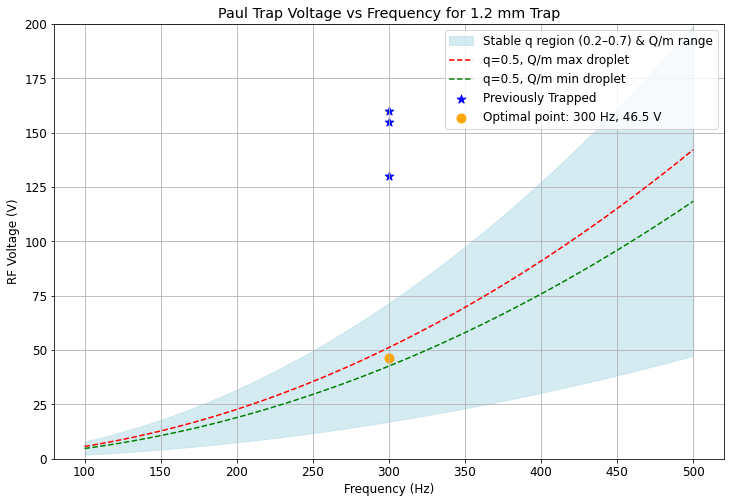

In [206]:

## Parameters 
r0 = 1.2e-3  # Trap radius (m)
f = np.linspace(100,500)  # Frequencies in Hz

## Droplet Q/m range 48-55 µm ethanol drops

#Q_m_min = 0.1615939163498099 #C/kg approximating as a conducting sphere using diam = 50um
#Q_m_max = 0.026831751397988587 # C/kg using rayleigh limit with diam= 50
Q_m_min = 0.025  # C/kg, largest droplet  ##original numbers were 0.023 and 0.028
Q_m_max = 0.030  # C/kg, smallest droplet
##how did i get these numbers? 
##the charges were found using the rayleigh limit, but the mass was found using a representative range of diameters
#look at output of Q/m rayleight diam 46-55

## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max droplet')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min droplet')


plt.scatter(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,200))
plt.title('Paul Trap Voltage vs Frequency for 1.2 mm Trap')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


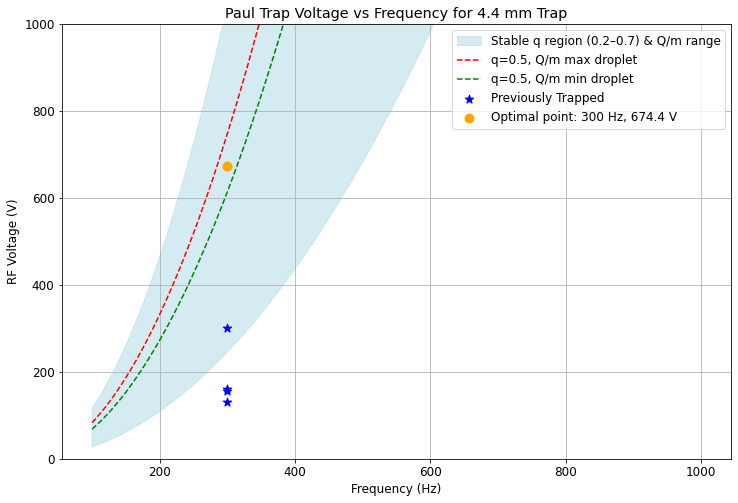

In [251]:

## Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,1000 ,500)  # Frequencies in Hz

## Droplet Q/m range 48-55 µm ethanol drops

#Q_m_min = 0.1615939163498099 #C/kg approximating as a conducting sphere using diam = 50um
#Q_m_max = 0.026831751397988587 # C/kg using rayleigh limit with diam= 50
Q_m_min = 0.023  # C/kg, largest droplet  ##original numbers were 0.023 and 0.028
Q_m_max = 0.028  # C/kg, smallest droplet
##how did i get these numbers? 
##the charges were found using the rayleigh limit, but the mass was found using a representative range of diameters
#look at output of Q/m rayleight diam 46-55

## Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

## RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

## Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

##  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

## Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max droplet')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min droplet')


plt.scatter(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,1000))
#plt.xlim((0,1000))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


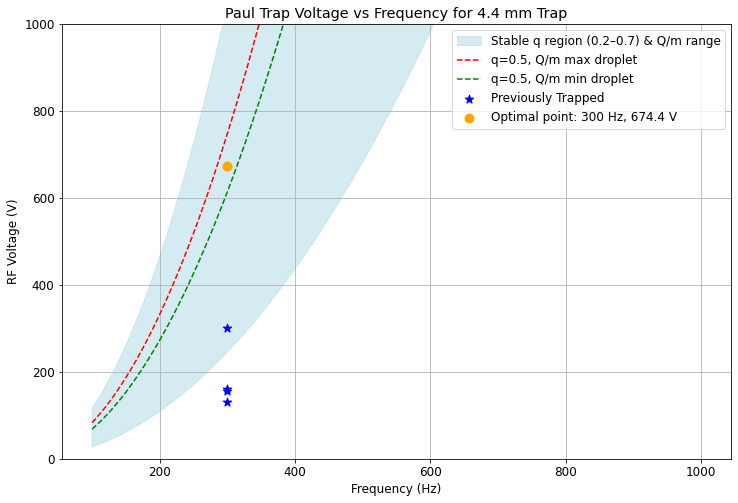

In [253]:

# Parameters 
r0 = 4.4e-3  # Trap radius (m)
f = np.linspace(100,1000,500)  # Frequencies in Hz

## Droplet Q/m range (48-55 µm ethanol drops) 


Q_m_min = 0.023
Q_m_max = 0.028
#Q_m_min = 0.1615939163498099 #C/kg approximating as a conducting sphere using diam = 50um
#Q_m_max = 0.026831751397988587 # C/kg using rayleigh limit with diam= 50

# Stability parameter q 
q_low = 0.2
q_nom = 0.5
q_high = 0.7

# RF voltage calculation
def V_RF(Q_m, q, f):
    return (q * r0**2 * (2 * np.pi * f)**2) / (2 * Q_m)

# Voltages for full stability envelope
V_low = V_RF(Q_m_max, q_low, f)
V_high = V_RF(Q_m_min, q_high, f)

#  Voltages for nominal q lines
V_nom_min = V_RF(Q_m_min, q_nom, f)
V_nom_max = V_RF(Q_m_max, q_nom, f)

# Optimal operating point
f_opt = 300  # Hz
Q_m_opt = (Q_m_min + Q_m_max)/2  # midpoint Q/m
q_opt = 0.5
V_opt = V_RF(Q_m_opt, q_opt, f_opt)

plt.figure(figsize=(12,8))
plt.fill_between(f, V_low, V_high, color='lightblue', alpha=0.5, label='Stable q region (0.2–0.7) & Q/m range')
plt.plot(f, V_nom_min, 'r--', label='q=0.5, Q/m max droplet')
plt.plot(f, V_nom_max, 'g--', label='q=0.5, Q/m min droplet')


plt.scatter(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1, s=80 ,marker='*',color='blue')

plt.scatter(f_opt, V_opt, color='orange', s=80, label=f'Optimal point: {f_opt} Hz, {V_opt:.1f} V')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
plt.ylim((0,1000))
plt.title('Paul Trap Voltage vs Frequency for 4.4 mm Trap')

plt.rcParams.update({'font.size': 12})
plt.legend()
plt.grid(True)
plt.show()


In [233]:
print(charge_to_mass_ratio)

[[0.02367722 0.02445349 0.02523805 0.02603084 0.02683175 0.02764072
  0.02845765]]


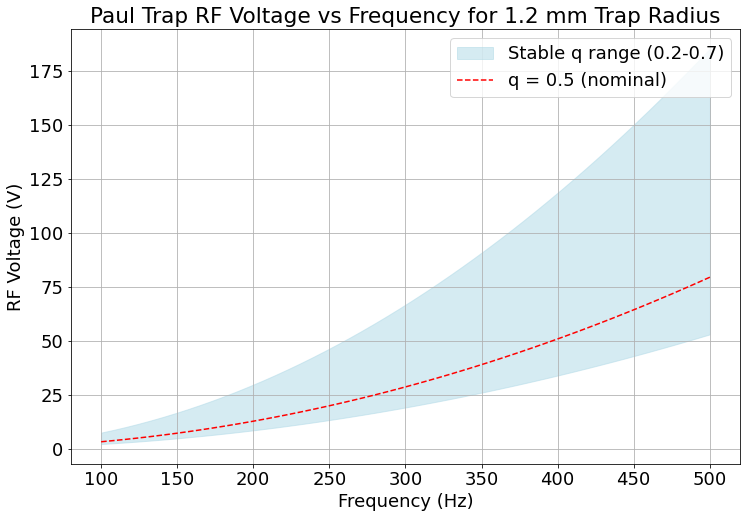

In [276]:


# Parameters
r0 = 1.2e-3  # Trap radius in meters
charge_to_mass_ratio = Q_rayleigh/drop_mass_kg  # Charge-to-mass ratio in C/kg
q_values = [0.2, 0.3, 0.7]  # Stability range for q
f = np.linspace(100, 500)  # Frequencies in Hz

# Computing Voltages
# Formula: V_RF = (q * r0^2 * (2*pi*f)^2) / (2*Q/m)
V_q_low = (q_values[0] * r0**2 * (2*np.pi*f)**2) / (2 * charge_to_mass_ratio)
V_q_nom = (q_values[1] * r0**2 * (2*np.pi*f)**2) / (2 * charge_to_mass_ratio)
V_q_high = (q_values[2] * r0**2 * (2*np.pi*f)**2) / (2 * charge_to_mass_ratio)



plt.figure(figsize=(12,8))
plt.fill_between(f, V_q_low, V_q_high, color='lightblue', alpha=0.5, label='Stable q range (0.2-0.7)')
plt.plot(f, V_q_nom, 'r--', label='q = 0.5 (nominal)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RF Voltage (V)')
#plt.ylim((0,40))
plt.title('Paul Trap RF Voltage vs Frequency for 1.2 mm Trap Radius')
plt.legend()
plt.grid(True)
plt.show()


# Uses rayleigh limit

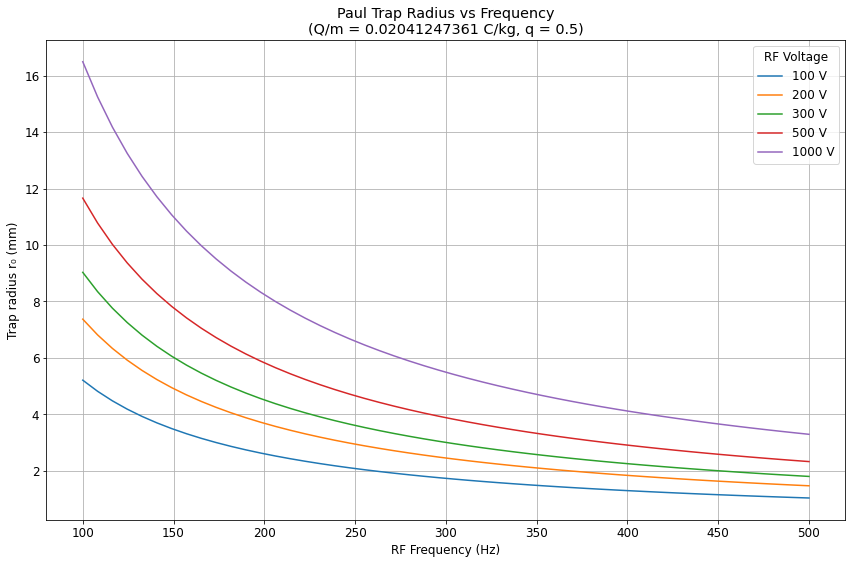

In [256]:
# Fixed parameters
charge_to_mass_ratio = Q_rayleigh/drop_mass_kg  # C/kg 
q = 0.5     # Mathieu stability parameter (typical)
freq = np.linspace(100, 500)  # Hz

# RF voltages to compare
voltages = [100, 200, 300, 500, 1000]  # volts


# Trap radius formula is  r0 = sqrt( 2(Q/m)V / ( q (2πf)^2 ) )
def trap_radius(V, f):
    return np.sqrt((2 * charge_to_mass_ratio * V) / (q * (2*np.pi*f)**2))

plt.figure(figsize=(12,8))

for V in voltages:
    r0 = trap_radius(V, freq)
    plt.plot(freq, r0*1e3, label=f"{V} V")  # convert to mm


plt.xlabel("RF Frequency (Hz)")
plt.ylabel("Trap radius r₀ (mm)")
plt.title("Paul Trap Radius vs Frequency\n(Q/m = 0.02041247361 C/kg, q = 0.5)")
plt.grid(True)
plt.legend(title="RF Voltage")

plt.tight_layout()
plt.show()


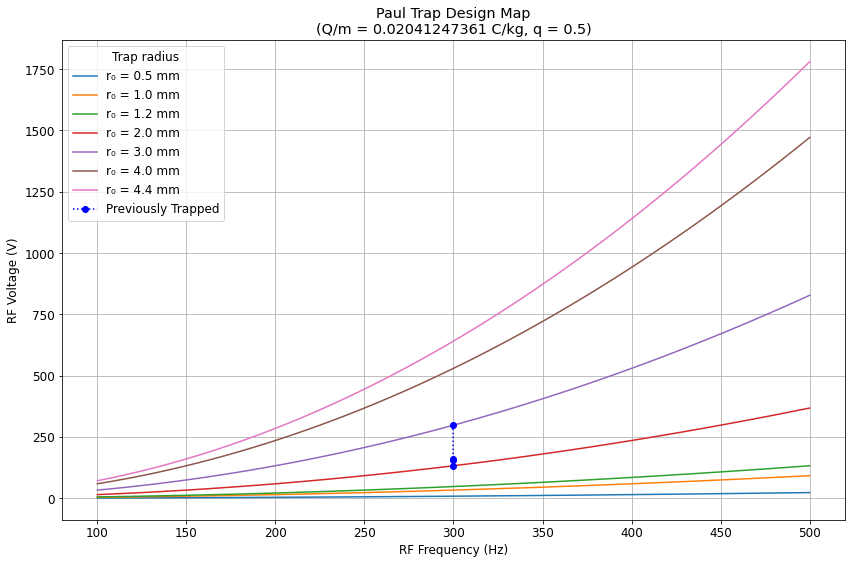

In [53]:

# Fixed parameters
charge_to_mass_ratio = Q_rayleigh/drop_mass_kg  # C/kg
q = 0.5             # Mathieu parameter (typical stable value)

# Frequency range
f = np.linspace(100, 500)  # Hz

# Trap radii to plot (in mm)
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * charge_to_mass_ratio)


plt.figure(figsize=(12,8))

for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm")

plt.plot(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1,marker='o',color='blue',linestyle='dotted')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.title("Paul Trap Design Map\n(Q/m = 0.02041247361 C/kg, q = 0.5)")
plt.grid(True)
plt.legend(title="Trap radius")

plt.tight_layout()
plt.show()


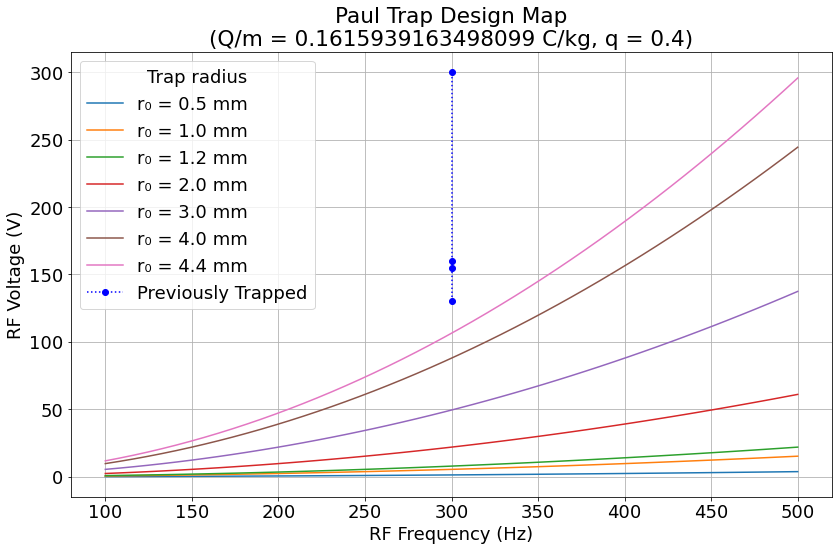

In [82]:
# Fixed parameters
Q_m_1=Q_1/drop_mass_kg 
#Q_m_1 = 0.1615939163498099 # C/kg
q = 0.5         # Mathieu stability parameter 

# Frequency range
f = np.linspace(100 ,500)  # Hz

# Trap radii to plot (in mm)
radii_mm = [0.5, 1.0, 1.2, 2.0, 3.0, 4.0, 4.4]

# Convert to meters
radii = [r*1e-3 for r in radii_mm]

# Voltage formula:
# V = q * r0^2 * (2πf)^2 / (2 * Q/m)

def V_RF(r0, f):
    return (q * r0**2 * (2*np.pi*f)**2) / (2 * Q_m_1)


plt.figure(figsize=(12,8))

for r0, rmm in zip(radii, radii_mm):
    V = V_RF(r0, f)
    plt.plot(f, V, label=f"r₀ = {rmm} mm")

plt.plot(PT_volts_list,PT_freq_list,label='Previously Trapped',alpha=1,marker='o',color='blue',linestyle='dotted')
plt.xlabel("RF Frequency (Hz)")
plt.ylabel("RF Voltage (V)")
plt.title("Paul Trap Design Map\n(Q/m = 0.1615939163498099 C/kg, q = 0.4)")
plt.grid(True)
plt.legend(title="Trap radius")

plt.tight_layout()
plt.show()


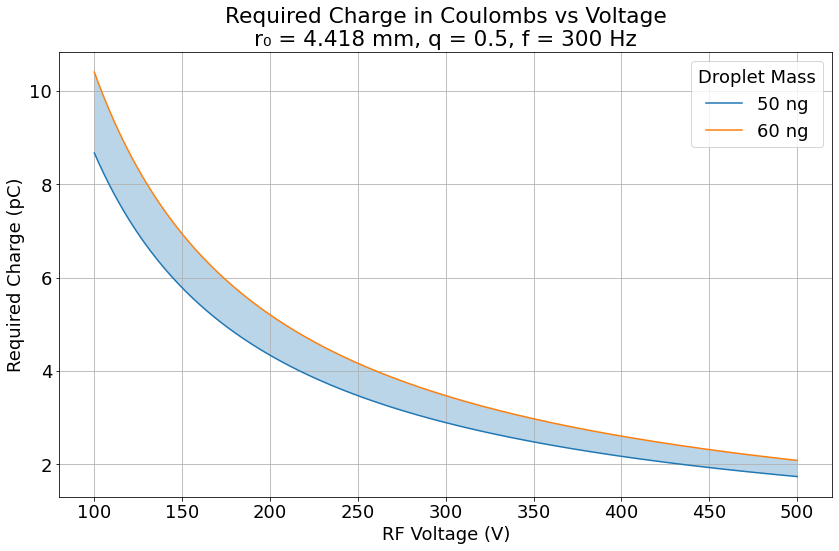

In [84]:


# Fixed parameters

r0 = 4.418e-3          # trap radius in meters
q = 0.5
f = 300                # Hz
Omega = 2*np.pi*f      # angular frequency

# Mass range (kg)
m_min = 50e-12
m_max = 60e-12

# Voltage range
V = np.linspace(100, 500, 300) ###This voltage is the RF Drive voltage on the PT rods, NOT the voltage in the electrospray or inkjet


# Charge formula is Q = (q * m * r0^2 * Omega^2) / (2 * V)

def required_charge(m, V):
    return (q * m * r0**2 * Omega**2) / (2 * V)

Q_min = required_charge(m_min, V)
Q_max = required_charge(m_max, V)

plt.figure(figsize=(12,8))

plt.plot(V, Q_min*1e12, label="50 ng")
plt.plot(V, Q_max*1e12, label="60 ng")

plt.fill_between(V, Q_min*1e12, Q_max*1e12, alpha=0.3)

plt.xlabel("RF Voltage (V)")
plt.ylabel("Required Charge (pC)")
plt.title("Required Charge in Coulombs vs Voltage\n"
          "r₀ = 4.418 mm, q = 0.5, f = 300 Hz")

plt.grid(True)
plt.legend(title="Droplet Mass")

plt.tight_layout()
plt.show()


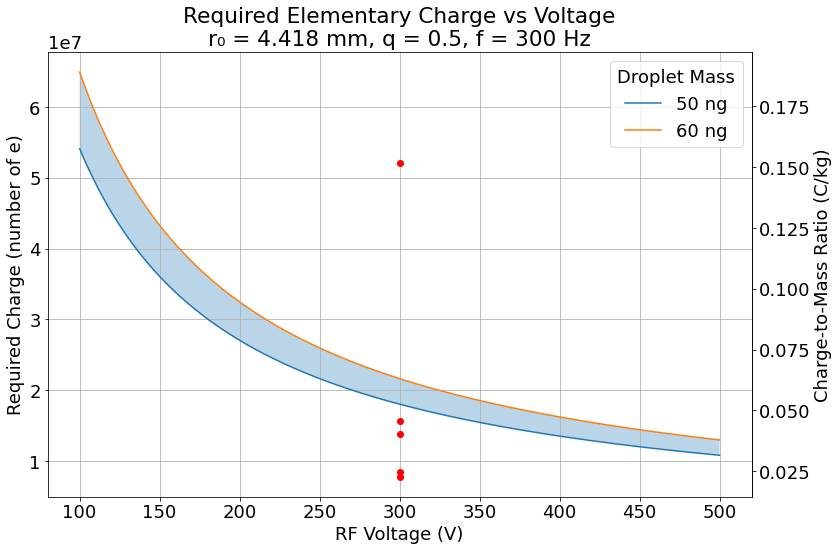

In [260]:
##Constants
e = 1.602176634e-19   # elementary charge (C)

##Trap parameters
r0 = 4.418e-3         # meters
q = 0.5
f = 300               # Hz
Omega = 2*np.pi*f

##Mass range (kg)
m_min = 50e-12
m_max = 60e-12
m_mid = 0.5*(m_min + m_max)

##Voltage range
V = np.linspace(100, 500 , 300) ###This voltage is the RF Drive voltage on the PT rods, NOT the voltage in the electrospray or inkjet


## Required charge is given by Q = (q * m * r0^2 * Omega^2) / (2 * V)

def required_charge(m, V):
    return (q * m * r0**2 * Omega**2) / (2 * V)

Q_min = required_charge(m_min, V)
Q_max = required_charge(m_max, V)
Q_mid = required_charge(m_mid, V)

##Converting to elementary charges
N_min = Q_min / e
N_max = Q_max / e
N_mid = Q_mid / e


fig, ax1 = plt.subplots(figsize=(12,8))

##Primary axis: elementary charges
ax1.plot(V, N_min, label="50 ng")
ax1.plot(V, N_max, label="60 ng")
ax1.fill_between(V, N_min, N_max, alpha=0.3)

ax1.set_xlabel("RF Voltage (V)")
ax1.set_ylabel("Required Charge (number of e)")
ax1.set_title("Required Elementary Charge vs Voltage\n"
              "r₀ = 4.418 mm, q = 0.5, f = 300 Hz")
ax1.grid(True)
ax1.legend(title="Droplet Mass")


RF_voltages = np.array([300, 300, 300, 300, 300])
measured_charges_e = np.array([
    7813141,
    8507642,
    13890028,
    15626282, 
    52087607
])

# Overlay measured points
plt.scatter(RF_voltages, measured_charges_e,
            color='red', zorder=5,
            label="Previously Trapped")

##Secondary axis for Q/m

def N_to_Qm(N):
    Q = N * e
    return Q / m_mid

def Qm_to_N(Qm):
    Q = Qm * m_mid
    return Q / e

ax2 = ax1.secondary_yaxis('right', functions=(N_to_Qm, Qm_to_N))
ax2.set_ylabel("Charge-to-Mass Ratio (C/kg)")

plt.tight_layout()
plt.show()


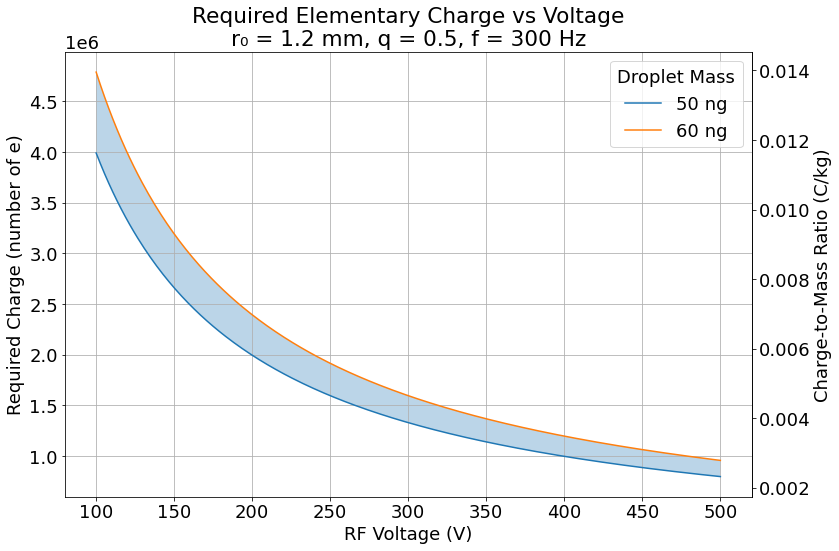

In [270]:
##Constants
e = 1.602176634e-19   # elementary charge (C)

##Trap parameters
r0 = 1.2e-3         # meters
q = 0.5
f = 300               # Hz
Omega = 2*np.pi*f

##Mass range (kg)
m_min = 50e-12
m_max = 60e-12
m_mid = 0.5*(m_min + m_max)

##Voltage range
V = np.linspace(100, 500 , 300) ###This voltage is the RF Drive voltage on the PT rods, NOT the voltage in the electrospray or inkjet


## Required charge is given by Q = (q * m * r0^2 * Omega^2) / (2 * V)

def required_charge(m, V):
    return (q * m * r0**2 * Omega**2) / (2 * V)

Q_min = required_charge(m_min, V)
Q_max = required_charge(m_max, V)
Q_mid = required_charge(m_mid, V)

##Converting to elementary charges
N_min = Q_min / e
N_max = Q_max / e
N_mid = Q_mid / e


fig, ax1 = plt.subplots(figsize=(12,8))

##Primary axis: elementary charges
ax1.plot(V, N_min, label="50 ng")
ax1.plot(V, N_max, label="60 ng")
ax1.fill_between(V, N_min, N_max, alpha=0.3)

ax1.set_xlabel("RF Voltage (V)")
ax1.set_ylabel("Required Charge (number of e)")
ax1.set_title("Required Elementary Charge vs Voltage\n"
              "r₀ = 1.2 mm, q = 0.5, f = 300 Hz")
ax1.grid(True)
ax1.legend(title="Droplet Mass")


##Secondary axis for Q/m

def N_to_Qm(N):
    Q = N * e
    return Q / m_mid

def Qm_to_N(Qm):
    Q = Qm * m_mid
    return Q / e

ax2 = ax1.secondary_yaxis('right', functions=(N_to_Qm, Qm_to_N))
ax2.set_ylabel("Charge-to-Mass Ratio (C/kg)")

plt.tight_layout()
plt.show()


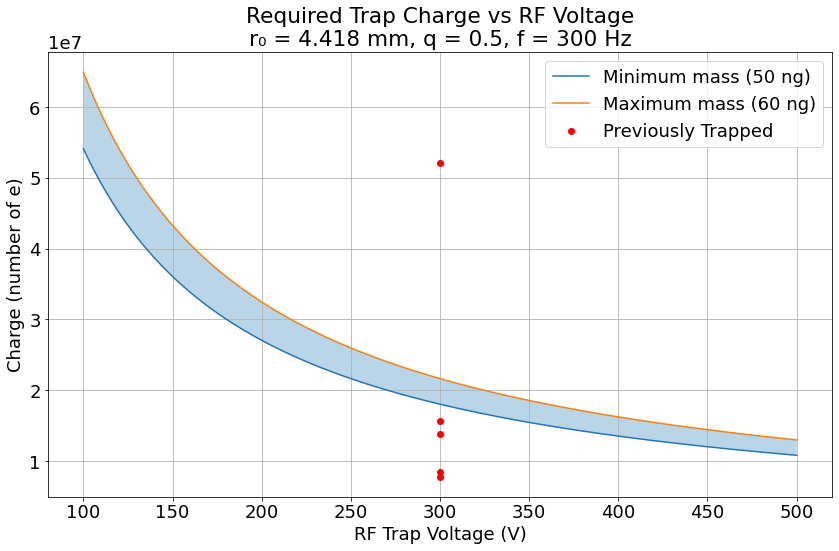

In [262]:

# Constants
e = 1.602176634e-19  # elementary charge (C)

# Trap parameters
r0 = 4.418e-3 #meters
q = 0.5 #Matthieu parameter, .5 choosen arb as trapping occurs from 0.2-0.7
f = 300 #Hz
Omega = 2*np.pi*f #angular freq

# Mass range in kg. This is just the upper and lower limit of drops i have measured in size and converted to mass
m_min = 50e-12
m_max = 60e-12

# RF voltage range (trap voltage)
V = np.linspace(100, 500, 300)

# Required charge formula
def required_charge(m, V):
    return (q * m * r0**2 * Omega**2) / (2 * V)

Q_min = required_charge(m_min, V)
Q_max = required_charge(m_max, V)

# Convert to elementary charges
N_min = Q_min / e
N_max = Q_max / e

# conducting-sphere approximation

RF_voltages = np.array([300, 300, 300, 300, 300])
measured_charges_e = np.array([
    7813141,
    8507642,
    13890028,
    15626282, 
    52087607
])


plt.figure(figsize=(12,8))

# Required band
plt.plot(V, N_min, label="Minimum mass (50 ng)")
plt.plot(V, N_max, label="Maximum mass (60 ng)")
plt.fill_between(V, N_min, N_max, alpha=0.3)

# Overlay measured points
plt.scatter(RF_voltages, measured_charges_e,
            color='red', zorder=5,
            label="Previously Trapped")



plt.xlabel("RF Trap Voltage (V)")
plt.ylabel("Charge (number of e)")
plt.title("Required Trap Charge vs RF Voltage\n"
          "r₀ = 4.418 mm, q = 0.5, f = 300 Hz")
plt.grid(True)
plt.legend()

plt.rcParams.update({'font.size': 18})

plt.tight_layout()
plt.show()


Required Q/m from trap: 0.05779262528821454 C/kg


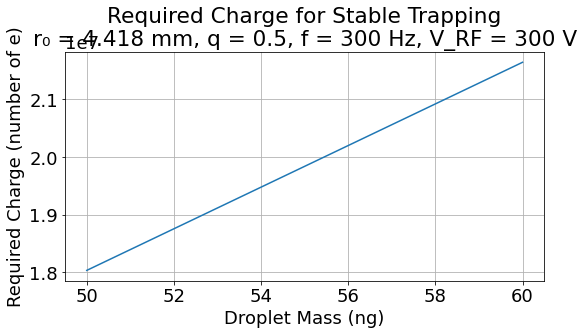

In [266]:
#### Constants
e = 1.602176634e-19  # elementary charge (C)

## Trap parameters (fixed)
r0 = 4.418e-3
q = 0.5
f = 300
Omega = 2*np.pi*f
V_RF = 300  # fixed rod voltage


# Required Q/m from trap

Q_m_required = (q * r0**2 * Omega**2) / (2 * V_RF)

print("Required Q/m from trap:", Q_m_required, "C/kg")


# Mass range (kg)

m = np.linspace(50e-12, 60e-12, 200)

# Required charge
Q_required = Q_m_required * m
N_required = Q_required / e  # elementary charges


plt.figure(figsize=(8,5))
plt.plot(m*1e12, N_required)

plt.xlabel("Droplet Mass (ng)")
plt.ylabel("Required Charge (number of e)")
plt.title("Required Charge for Stable Trapping\n"
          "r₀ = 4.418 mm, q = 0.5, f = 300 Hz, V_RF = 300 V")
plt.grid(True)

plt.tight_layout()
plt.show()


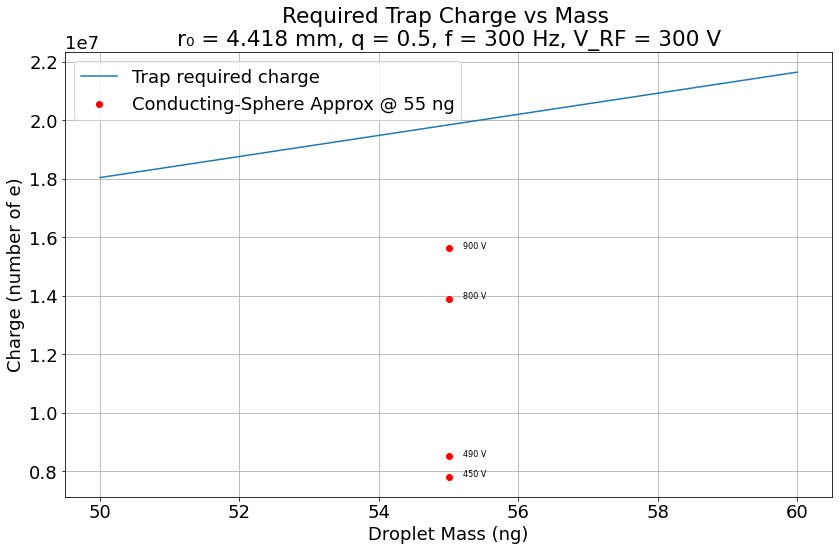

In [71]:



# Constants

e = 1.602176634e-19  # elementary charge (C)

# Trap parameters (fixed)
r0 = 4.418e-3
q = 0.5
f = 300
Omega = 2*np.pi*f
V_RF = 300  # fixed rod voltage


# Required Q/m from trap

Q_m_required = (q * r0**2 * Omega**2) / (2 * V_RF)

# Mass range (kg)
m = np.linspace(50e-12, 60e-12, 200)

# Required charge curve
Q_required = Q_m_required * m
N_required = Q_required / e  # convert to elementary charges


# Your measured charges (in e)

spray_voltages_3kV= [450, 490, 800, 900] ##52087607 charges, at 3kV on electrospray
measured_charges_e_3kV = [
    7813141,
    8507642,
    13890028,
    15626282
]

# Assume midpoint mass (55 ng)
mass_point = 55e-12
mass_point_ng = 55

plt.figure(figsize=(12,8))

# Required region
plt.plot(m*1e12, N_required, label="Trap required charge")

# Overlay your electrospray-derived points
plt.scatter(
    [mass_point_ng]*len(measured_charges_e_3kV),
    measured_charges_e,
    color='red',
    zorder=5,
    label="Conducting-Sphere Approx @ 55 ng"
)

# Label each point with spray voltage
for v, q_e in zip(spray_voltages_3kV, measured_charges_e_3kV):
    plt.text(mass_point_ng + 0.2, q_e, f"{v} V", fontsize=8)

plt.xlabel("Droplet Mass (ng)")
plt.ylabel("Charge (number of e)")
plt.title("Required Trap Charge vs Mass \n"
          "r₀ = 4.418 mm, q = 0.5, f = 300 Hz, V_RF = 300 V")

plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


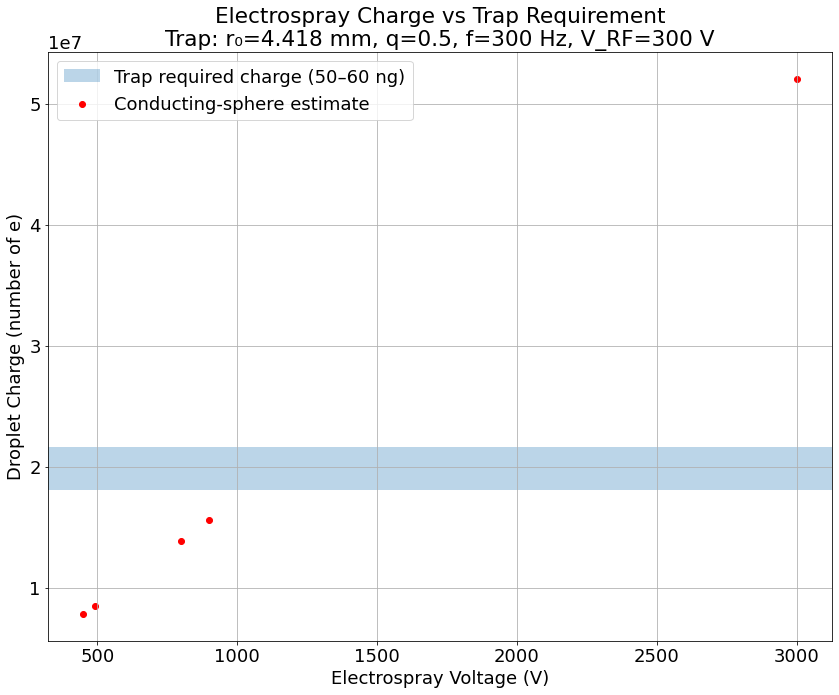

In [76]:

# Constants

e = 1.602176634e-19

# Trap parameters
r0 = 4.418e-3
q = 0.5
f = 300
Omega = 2*np.pi*f
V_RF = 300  # trap rod voltage (fixed)

# Required Q/m
Q_m_required = (q * r0**2 * Omega**2) / (2 * V_RF)

# Mass range
m_min = 50e-12
m_max = 60e-12

# Required charge band
Q_required_min = Q_m_required * m_min
Q_required_max = Q_m_required * m_max

N_required_min = Q_required_min / e
N_required_max = Q_required_max / e

# electrospray voltages

spray_voltages_3kV = np.array([450, 490, 800, 900, 3000])
measured_charges_e_3kV = np.array([
    7813141,
    8507642,
    13890028,
    15626282,
    52087607
])

plt.figure(figsize=(12,10))

# Required horizontal band
plt.axhspan(N_required_min, N_required_max,
            alpha=0.3,
            label="Trap required charge (50–60 ng)")

# Measured points
plt.scatter(spray_voltages_3kV, measured_charges_e_3kV,
            color='red',
            label="Conducting-sphere estimate")

plt.xlabel("Electrospray Voltage (V)")
plt.ylabel("Droplet Charge (number of e)")
plt.title("Electrospray Charge vs Trap Requirement\n"
          "Trap: r₀=4.418 mm, q=0.5, f=300 Hz, V_RF=300 V")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


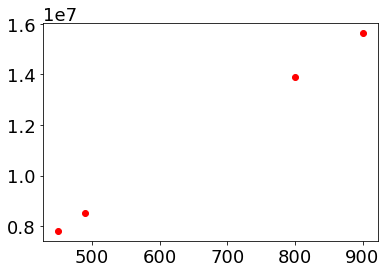

In [78]:
##Electrospray voltages

spray_voltages = np.array([450, 490, 800, 900])
measured_charges_e = np.array([
    7813141,
    8507642,
    13890028,
    15626282
])
##Overlay measured points
plt.scatter(spray_voltages, measured_charges_e,
            color='red', zorder=5,
            label="Previously Trapped")